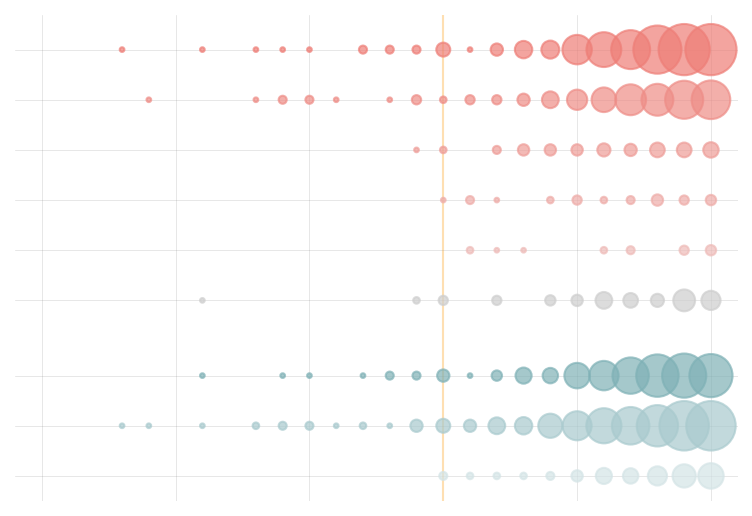

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.ticker as ticker

# 设置样式
plt.style.use('default')
plt.rcParams["font.sans-serif"] = ["Arial"]
plt.rcParams["axes.unicode_minus"] = False

# 读取数据
df = pd.read_csv(r"D:\CDT\03-数据\count_v3.csv")

# 创建图表
fig, ax = plt.subplots(figsize=(13 / 2.54, 9 / 2.54), dpi=150)

# 定义所有数据系列的颜色
colors = {
    'Cluster1': '#ee7e77',
    'Cluster2': '#ee8d87',
    'Cluster3': '#ee9d98',
    'Cluster4': '#eeaca8',
    'Cluster5': '#eebbb8',
    'Cluster0': '#cecece',
    'High': '#7fb1b6',
    'Moderate': '#A9CACE',
    'Low': '#D4E4E6'
}

# 顺序从上到下依次为 Cluster1 到 Cluster0，然后 High Moderate Low
series_list = ['Cluster1', 'Cluster2', 'Cluster3', 'Cluster4', 'Cluster5', 'Cluster0', 'High', 'Moderate', 'Low']

# 创建y轴位置映射（从上到下），在Cluster0和High之间添加0.5的间隔
y_positions = []
position_map = {}
current_y = len(series_list) - 1  # 从最上面开始

for i, series in enumerate(series_list):
    # 在Cluster0和High之间添加半行间距
    if series == 'High':
        current_y -= 0.5  # 增加半行间距（从上到下，所以是减）
    position_map[series] = current_y
    y_positions.append(current_y)
    current_y -= 1

# 先画横竖线（置于底层）
# 每五年画竖线（2000, 2005, 2010, ..., 2025）
for year in range(2000, 2026, 5):
    if year == 2015:
        # 2015年竖线特殊样式
        ax.axvline(x=year, color='#fedfb2', linestyle='-', alpha=1, linewidth=1, zorder=1)
    else:
        ax.axvline(x=year, color='gray', linestyle='-', alpha=0.3, linewidth=0.3, zorder=1)

# 每一行画横线（在气泡中心穿过）- 使用新的位置
for pos in sorted(y_positions, reverse=True):  # 从大到小排序，确保正确绘制
    ax.axhline(y=pos, color='gray', linestyle='-', alpha=0.3, linewidth=0.3, zorder=1)

# 再画气泡（置于上层）
for series in series_list:
    # 过滤掉值为0的数据点（不显示气泡）
    mask = df[series] > 0
    years = df['year'][mask]
    values = df[series][mask]

    ax.scatter(
        years,
        [position_map[series]] * len(years),  # 使用映射的位置
        s=values * 5,  # 气泡大小与数值成正比
        c=colors[series],
        alpha=0.7,
        zorder=2  # 气泡置于上层
    )

# 设置坐标轴范围
ax.set_xlim(1999, 2026)
min_y = min(y_positions) - 0.5
max_y = max(y_positions) + 0.7
ax.set_ylim(min_y, max_y)

# 设置y轴刻度和标签 - 保持正确的顺序
# 我们需要按照从上到下的顺序设置标签
sorted_indices = np.argsort(y_positions)[::-1]  # 从大到小排序的索引
sorted_y_positions = np.array(y_positions)[sorted_indices]
sorted_labels = np.array(series_list)[sorted_indices]

ax.set_yticks(sorted_y_positions)
ax.set_yticklabels(sorted_labels)

# 移除边框
for spine in ax.spines.values():
    spine.set_visible(False)

# 移除所有坐标轴标签、刻度和图例
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_xticks([])
ax.set_yticks([])
ax.set_xticklabels([])
ax.set_yticklabels([])

plt.tight_layout()

# 保存图片
plt.savefig(r"D:\CDT\04-结果\fig2_v3\fig2c2_v3.png", dpi=300, bbox_inches='tight')
plt.show()

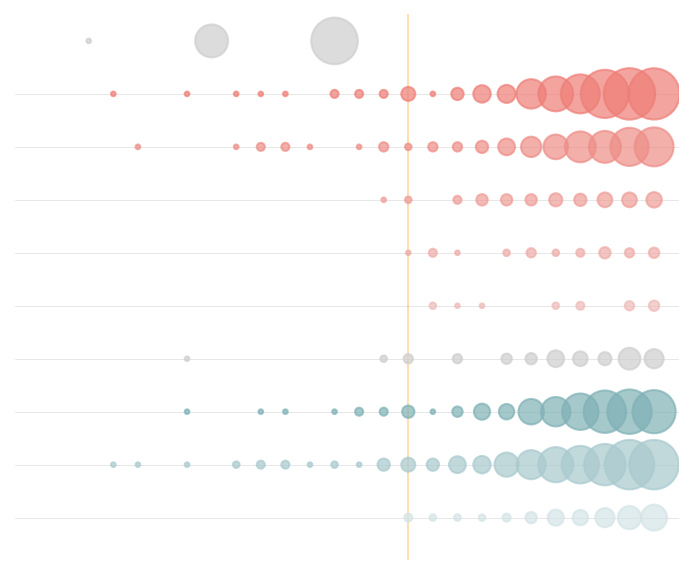

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.ticker as ticker

# 设置样式
plt.style.use('default')
plt.rcParams["font.sans-serif"] = ["Arial"]
plt.rcParams["axes.unicode_minus"] = False

# 读取数据
df = pd.read_csv(r"D:\CDT\03-数据\count_v3.csv")

# 创建图表
fig, ax = plt.subplots(figsize=(12 / 2.54, 10 / 2.54), dpi=150)

# 定义所有数据系列的颜色
colors = {
    'Cluster1': '#ee7e77',
    'Cluster2': '#ee8d87',
    'Cluster3': '#ee9d98',
    'Cluster4': '#eeaca8',
    'Cluster5': '#eebbb8',
    'Cluster0': '#cecece',
    'High': '#7fb1b6',
    'Medium': '#A9CACE',
    'Low': '#D4E4E6'
}

# 顺序：Cluster1到Cluster0，然后High Medium Low（从下到上）
series_list = ['Cluster1', 'Cluster2', 'Cluster3', 'Cluster4', 'Cluster5', 'Cluster0', 'High', 'Moderate', 'Low']

# 先画横竖线（置于底层）
# 每五年画竖线（2000, 2005, 2010, ..., 2025）
for year in range(2000, 2026, 5):
    if year == 2015:
        # 2015年竖线特殊样式
        ax.axvline(x=year, color='#fedfb2', linestyle='-', alpha=1, linewidth=1, zorder=1)
    else:
        ax.axvline(x=year, color='gray', linestyle='-', alpha=0, linewidth=0.3, zorder=1)

# 每一行画横线（在气泡中心穿过）- 除了最后一行（图例行）
for i in range(len(series_list)):  # 不画最后一行的横线
    ax.axhline(y=i, color='gray', linestyle='-', alpha=0.3, linewidth=0.3, zorder=1)

# 再画气泡（置于上层）
for i, series in enumerate(series_list):
    # 过滤掉值为0的数据点（不显示气泡）
    mask = df[series] > 0
    years = df['year'][mask]
    values = df[series][mask]

    ax.scatter(
        years,
        [len(series_list) - 1 - i] * len(years),  # 反转y轴位置
        s=values * 5,  # 气泡大小与数值成正比
        c=colors[series],
        alpha=0.7,
        zorder=2  # 气泡置于上层
    )

# 在最上面增加图例行（对应数值1, 100, 200）
legend_y_position = len(series_list)  # 最上面一行
legend_years = [2002, 2007, 2012]
legend_values = [1, 50, 100]

ax.scatter(
    legend_years,
    [legend_y_position] * len(legend_years),  # 最上面一行
    s=np.array(legend_values) * 5,  # 使用相同的大小比例
    c='#cecece',  # 图例颜色
    alpha=0.7,
    zorder=2
)

# 设置坐标轴范围 - 增加上方空间容纳图例行
ax.set_xlim(1999, 2026)
ax.set_ylim(-0.8, len(series_list) + 0.5)  # 增加上方空间

# 设置y轴刻度和标签（正确的顺序）- 不显示图例行的标签
ax.set_yticks(range(len(series_list)))
ax.set_yticklabels(series_list[::-1])  # 反转标签顺序

# 移除边框
for spine in ax.spines.values():
    spine.set_visible(False)

# 移除所有坐标轴标签、刻度和图例
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_xticks([])
ax.set_yticks([])
ax.set_xticklabels([])
ax.set_yticklabels([])

plt.tight_layout()

# 保存图片
plt.savefig(r"D:\CDT\04-结果\fig2c2_label_v3.png", dpi=300, bbox_inches='tight')
plt.show()

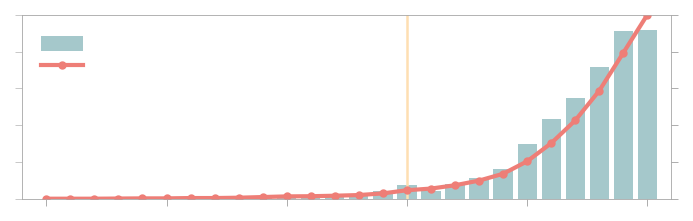

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

plt.style.use('default')

# 设置字体样式
plt.rcParams["font.sans-serif"] = ["Arial"]
plt.rcParams["axes.unicode_minus"] = False

# 读取数据
df = pd.read_csv(r"D:\CDT\03-数据\count_v3.csv")

# 修复数据逻辑（确保累计百分比正确）
df = df.sort_values(by='year')
df = df[(df['year'] >= 2000) & (df['year'] <= 2025)].copy()

fig, ax1 = plt.subplots(figsize=(12/2.54, 4/2.54), dpi=150, facecolor='white')
ax1.set_facecolor('white')

# 设置颜色
bar_color = '#7fb1b6'
line_color = '#ee7e77'

# 计算累积百分比
df['cumulative_all'] = df['all'].cumsum()
total_all = df['all'].sum()
df['cumulative_percentage'] = (df['cumulative_all'] / total_all) * 100

# 绘制条形图
bars = ax1.bar(df['year'], df['all'], color=bar_color, alpha=0.7, width=0.8)

# 设置左侧y轴
ax1.set_xlim(1999, 2026)
ax1.set_ylim(0, 250)
ax1.set_ylabel('')
ax1.set_xlabel('')
ax1.set_yticks(np.arange(0, 251, 50))
ax1.set_yticklabels([])
ax1.tick_params(axis='y', width=0.3, color='darkgray')

# 创建右侧y轴
ax2 = ax1.twinx()
ax2.set_ylabel('')
ax2.set_ylim(0, 100)
ax2.set_yticks(np.arange(0, 101, 20))
ax2.set_yticklabels([])
ax2.tick_params(axis='y', width=0.3, color='gray')

# 绘制折线图
line = ax2.plot(df['year'], df['cumulative_percentage'],
                color=line_color, linewidth=2, marker='o', markersize=3)

# 设置x轴
years = [2000, 2005, 2010, 2015, 2020, 2025]
ax1.set_xticks(years)
ax1.set_xticklabels([])
ax1.tick_params(axis='x', width=0.3, color='gray')

# 添加2015年竖线
ax1.axvline(x=2015, color='#fedfb2', linestyle='-', alpha=1, linewidth=1.2, zorder=1)

# 白色网格线（白底上灰色线）
# ax1.grid(True, color='gray', linestyle='-', linewidth=0.5, alpha=0.3)

# 设置边框样式
for spine in ax1.spines.values():
    spine.set_color('darkgray')
    spine.set_linewidth(0.3)
for spine in ax2.spines.values():
    spine.set_color('darkgray')
    spine.set_linewidth(0.3)

# 添加图例
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
legend_elements = [
    Patch(facecolor=bar_color, alpha=0.7),
    Line2D([0], [0], color=line_color, linewidth=2, marker='o', markersize=3)
]
ax1.legend(legend_elements, ['', ''], loc='upper left', frameon=False, labelspacing=0)

plt.tight_layout()

plt.savefig(r"D:\CDT\04-结果\fig2_v3\fig2c1_v3.png",
            dpi=300,
            bbox_inches='tight',
            facecolor='white') # 确保保存出来的图是白底

plt.show()